<a href="https://colab.research.google.com/github/pufferfish305206-sol/HUIT-TimeSeries-FastFood/blob/main/diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

==== KẾT QUẢ CHẨN ĐOÁN: Dữ Liệu Giả (Dummy) ====

	Box-Ljung test

data:  du_lieu_phan_du
X-squared = 7.4816, df = 10, p-value = 0.6793

=> ĐẠT YÊU CẦU: Phần dư là nhiễu trắng (p-value > 0.05).



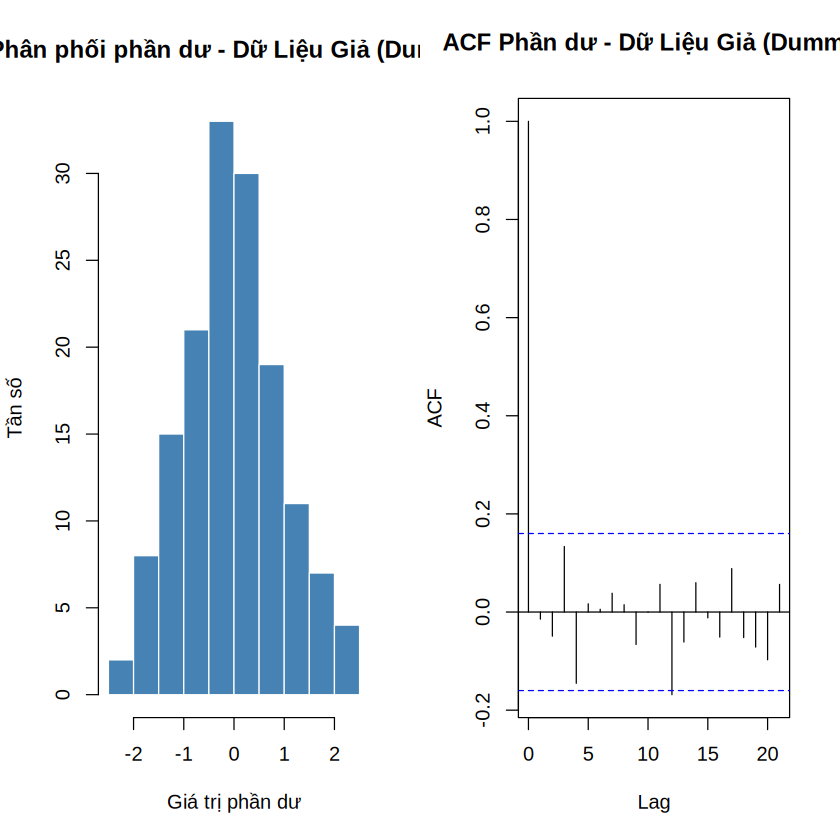

In [2]:
# =========================================================================
# NỘI DUNG 5A: HÀM CHẨN ĐOÁN PHẦN DƯ MÔ HÌNH
# =========================================================================

# 1. ĐỊNH NGHĨA HÀM CHUNG (Viết 1 lần, dùng mãi mãi)
chuan_doan_phan_du <- function(du_lieu_phan_du, ten_mo_hinh = "Mô hình") {

  cat(paste("==== KẾT QUẢ CHẨN ĐOÁN:", ten_mo_hinh, "====\n"))
  par(mfrow=c(1,2)) # Chia đôi màn hình vẽ

  # Vẽ Histogram
  hist(du_lieu_phan_du,
       main = paste("Phân phối phần dư -", ten_mo_hinh),
       xlab = "Giá trị phần dư", ylab = "Tần số", col = "steelblue", border = "white")

  # Vẽ đồ thị ACF
  acf(du_lieu_phan_du, main = paste("ACF Phần dư -", ten_mo_hinh))
  par(mfrow=c(1,1)) # Reset màn hình vẽ

  # Kiểm định Ljung-Box
  ljung_box_result <- Box.test(du_lieu_phan_du, lag = 10, type = "Ljung-Box")
  print(ljung_box_result)

  # Kết luận
  if(ljung_box_result$p.value > 0.05) {
    cat("=> ĐẠT YÊU CẦU: Phần dư là nhiễu trắng (p-value > 0.05).\n\n")
  } else {
    cat("=> KHÔNG ĐẠT: Phần dư CÒN tự tương quan (p-value <= 0.05). YÊU CẦU GRID SEARCH LẠI!\n\n")
  }
}

# =========================================================================
# 2. CHẠY TEST BẰNG DỮ LIỆU GIẢ (Thực hiện đúng yêu cầu phân công)
set.seed(123)
dummy_data <- rnorm(150)

# Gọi hàm chạy thử
chuan_doan_phan_du(dummy_data, "Dữ Liệu Giả (Dummy)")

# =========================================================================
# 3. KHI NÀO TV2 VÀ TV7 GỬI FILE, BẠN CHỈ CẦN THÊM 2 DÒNG NÀY Ở DƯỚI CÙNG:
# data_tv2 <- read.csv("ten_file_cua_tv2.csv")$ten_cot_phan_du
# chuan_doan_phan_du(data_tv2, "Mô hình ARIMA (TV2)")

# data_tv7 <- read.csv("ten_file_cua_tv7.csv")$ten_cot_phan_du
# chuan_doan_phan_du(data_tv7, "Mô hình SARIMA (TV7)")